## 3.Visulaisation

In [ ]:
import numpy as np
import pandas as pd

# Load original full dataset
df = pd.read_csv("single_genre_artists.csv")

# Load clusters
clusters = np.load("clusters.npy")

X_scaled = np.load("X_scaled.npy")

print("Loaded successfully!")
print(df.shape)
print(len(clusters))
print(X_scaled.shape)

# Attach clusters
df['cluster'] = clusters

In [2]:
print(df.shape)
print(len(clusters))

(95837, 24)
95837


In [3]:
df['cluster'].value_counts()

cluster
1    52295
0    31131
2    12411
Name: count, dtype: int64

In [4]:
cluster_summary = df.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

         popularity_songs    duration_ms  explicit  danceability    energy  \
cluster                                                                      
0               20.901288  218295.793293  0.006264      0.486985  0.313200   
1               28.698556  225557.122880  0.048838      0.627756  0.695247   
2               27.931351  113848.654661  0.007413      0.665010  0.463105   

              key   loudness      mode  speechiness  acousticness  \
cluster                                                             
0        5.136777 -13.121578  0.674055     0.056705      0.746319   
1        5.271231  -7.605039  0.631093     0.076147      0.256415   
2        5.033599 -13.480433  0.654419     0.840626      0.591829   

         instrumentalness  liveness   valence       tempo  time_signature  \
cluster                                                                     
0                0.164330  0.181354  0.414359  112.049278        3.794449   
1                0.052364  0.201

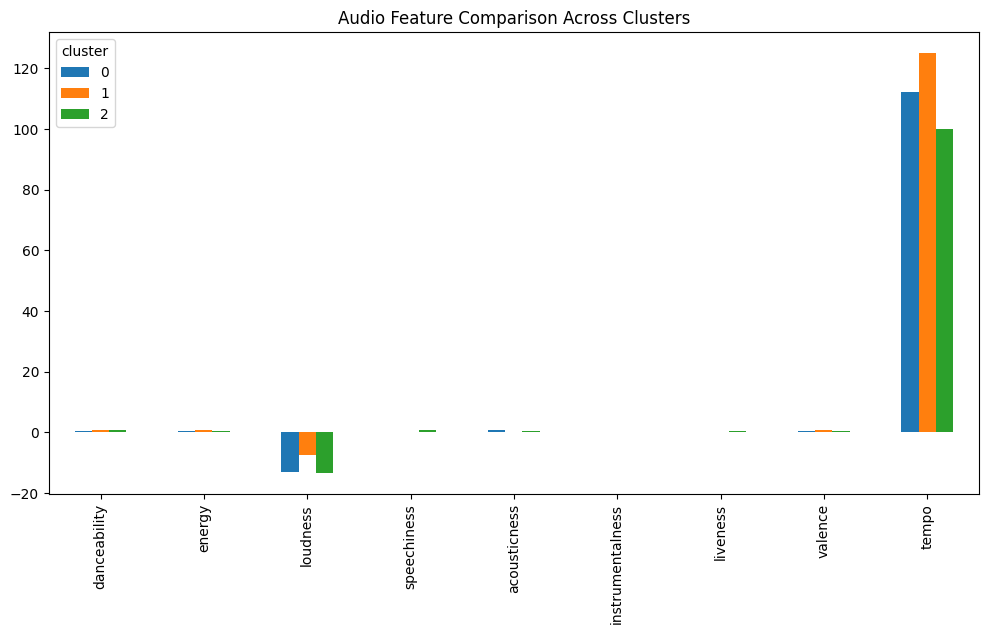

In [ ]:
import matplotlib.pyplot as plt

audio_features = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence', 'tempo'
]

cluster_summary[audio_features].T.plot(kind='bar', figsize=(12,6))
plt.title("Audio Feature Comparison Across Clusters")
plt.show()

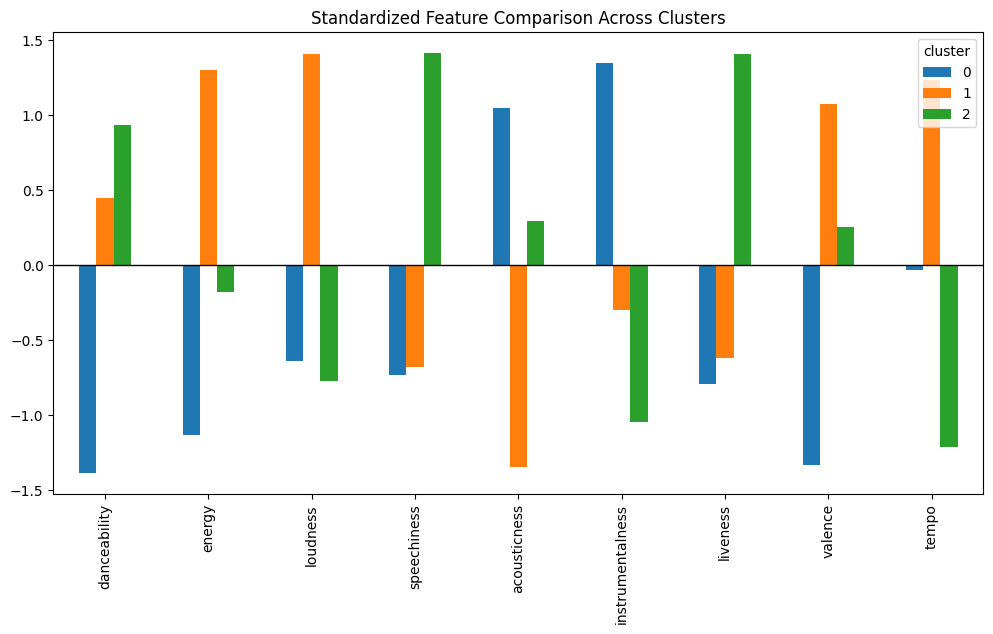

In [29]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

audio_features = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness',
    'instrumentalness', 'liveness',
    'valence', 'tempo'
]

scaled_summary = pd.DataFrame(
    scaler.fit_transform(cluster_summary[audio_features]),
    columns=audio_features,
    index=cluster_summary.index
)

scaled_summary.T.plot(kind='bar', figsize=(12,6))
plt.title("Standardized Feature Comparison Across Clusters")
plt.axhline(0, color='black', linewidth=1)  # important reference line
plt.show()

In [14]:
cluster_names = {
    0: "Instrumental / Calm",
    1: "Energetic / Mainstream",
    2: "Live / Vocal Heavy"
}

df['cluster_name'] = df['cluster'].map(cluster_names)

In [15]:
df['cluster_name'].value_counts()

cluster_name
Energetic / Mainstream    52295
Instrumental / Calm       31131
Live / Vocal Heavy        12411
Name: count, dtype: int64

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])

[[-1.67945849  0.12909869]
 [-2.7091678  -0.34398672]
 [-2.57467095  0.64232987]
 [-0.65930714  0.57983987]
 [-1.45731056  1.49129036]]


In [19]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = labels

pca_df.head()

,PC1,PC2,cluster
0,-1.679458,0.129099,0
1,-2.709168,-0.343987,0
2,-2.574671,0.642330,0
3,-0.659307,0.579840,0
4,-1.457311,1.491290,0


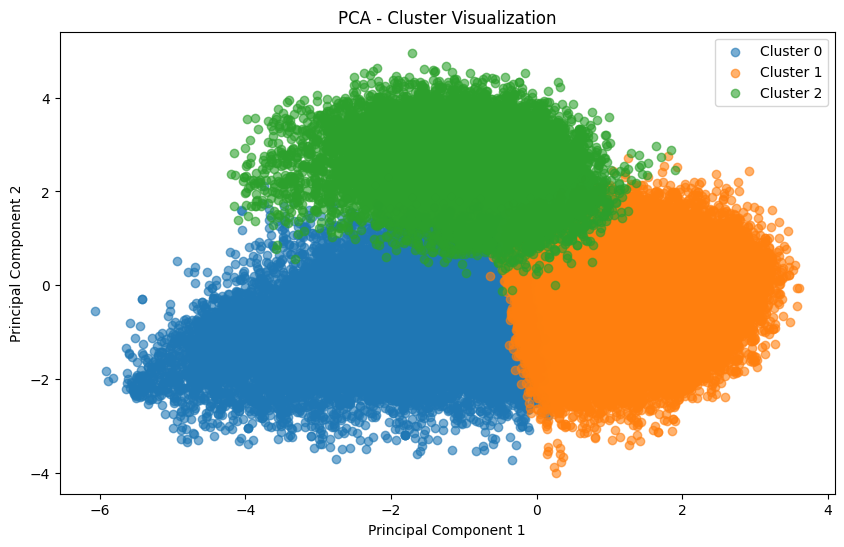

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Cluster Visualization")
plt.legend()
plt.show()

In [23]:
import pandas as pd
import numpy as np

df_original = pd.read_csv(r"D:\Viki\Guvi DS\Capstone Projects\Amazon Music Clustering\notebook\non_featured_data.csv")
labels = np.load("clusters.npy")

In [24]:
df_original['cluster'] = labels

In [26]:
for cluster in sorted(df_original['cluster'].unique()):
    
    print(f"\nCluster {cluster} - {cluster_names[cluster]}")
    print("-" * 50)
    
    top_genres = (
        df_original[df_original['cluster'] == cluster]['genres']
        .value_counts()
        .head(10)
    )
    
    print(top_genres)


Cluster 0 - Instrumental / Calm
--------------------------------------------------
genres
['vintage taiwan pop']     1050
['classic israeli pop']     565
['chanson']                 553
['classic soundtrack']      457
['opm']                     406
['classic thai pop']        395
['indonesian pop']          364
[]                          361
['rebetiko']                356
['turkish folk']            350
Name: count, dtype: int64

Cluster 1 - Energetic / Mainstream
--------------------------------------------------
genres
[]                           833
['j-pop']                    809
['turkish pop']              626
['classic thai pop']         544
['rock uruguayo']            521
['classic israeli pop']      520
['cumbia uruguaya']          483
['hoerspiel']                469
['indonesian pop']           449
['classic hungarian pop']    425
Name: count, dtype: int64

Cluster 2 - Live / Vocal Heavy
--------------------------------------------------
genres
['hoerspiel']          

In [27]:
for cluster in sorted(df_original['cluster'].unique()):
    
    print(f"\nCluster {cluster} - {cluster_names[cluster]}")
    print("-" * 50)
    
    top_artists = (
        df_original[df_original['cluster'] == cluster]['name_artists']
        .value_counts()
        .head(10)
    )
    
    print(top_artists)


Cluster 0 - Instrumental / Calm
--------------------------------------------------
name_artists
Charlie Chaplin                   297
Louis Armstrong & His Hot Five    239
Bill Evans                        176
Ahmet Kaya                        160
Charles Aznavour                  149
David and the High Spirit         149
Müslüm Gürses                     140
湯蘭花                               127
S. P. Balasubrahmanyam            115
Sezen Aksu                        114
Name: count, dtype: int64

Cluster 1 - Energetic / Mainstream
--------------------------------------------------
name_artists
Die drei ???              381
ARASHI                    226
S. P. Balasubrahmanyam    193
Karibe con K              175
Wings                     160
Boney M.                  152
Müslüm Gürses             141
Sezen Aksu                129
Prāta Vētra               122
Shogo Hamada              114
Name: count, dtype: int64

Cluster 2 - Live / Vocal Heavy
---------------------------------------

In [28]:
top_n = 5

for cluster in sorted(df_original['cluster'].unique()):
    
    print(f"\nCluster {cluster} - {cluster_names[cluster]}")
    print("-" * 50)
    
    top_artists = (
        df_original[df_original['cluster'] == cluster]['name_artists']
        .value_counts()
        .head(top_n)
    )
    
    for artist, count in top_artists.items():
        print(f"{artist} → {count}")


Cluster 0 - Instrumental / Calm
--------------------------------------------------
Charlie Chaplin → 297
Louis Armstrong & His Hot Five → 239
Bill Evans → 176
Ahmet Kaya → 160
Charles Aznavour → 149

Cluster 1 - Energetic / Mainstream
--------------------------------------------------
Die drei ??? → 381
ARASHI → 226
S. P. Balasubrahmanyam → 193
Karibe con K → 175
Wings → 160

Cluster 2 - Live / Vocal Heavy
--------------------------------------------------
Die drei ??? → 3384
TKKG Retro-Archiv → 1873
Benjamin Blümchen → 1487
Bibi Blocksberg → 1423
Fünf Freunde → 772


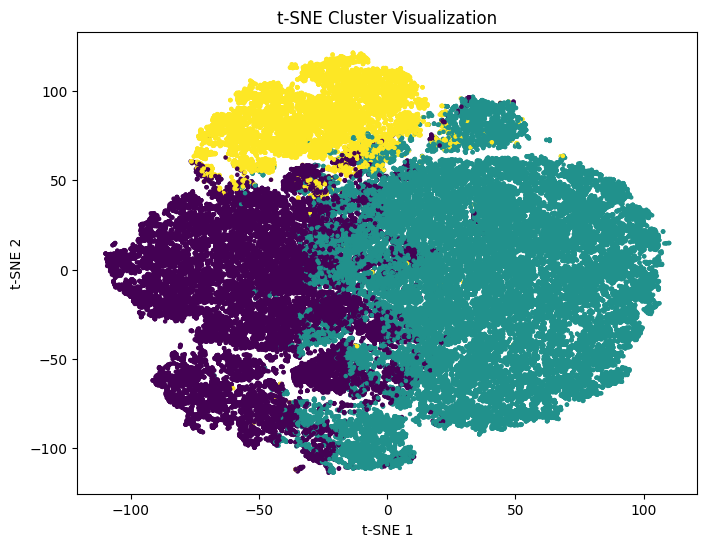

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels, cmap='viridis', s=5)
plt.title("t-SNE Cluster Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

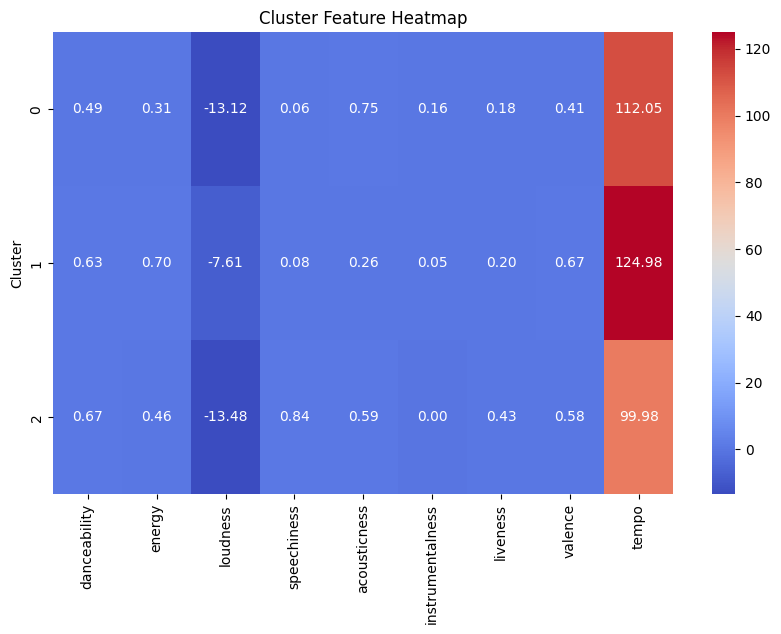

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary[audio_features], 
            annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Cluster Feature Heatmap")
plt.ylabel("Cluster")
plt.show()

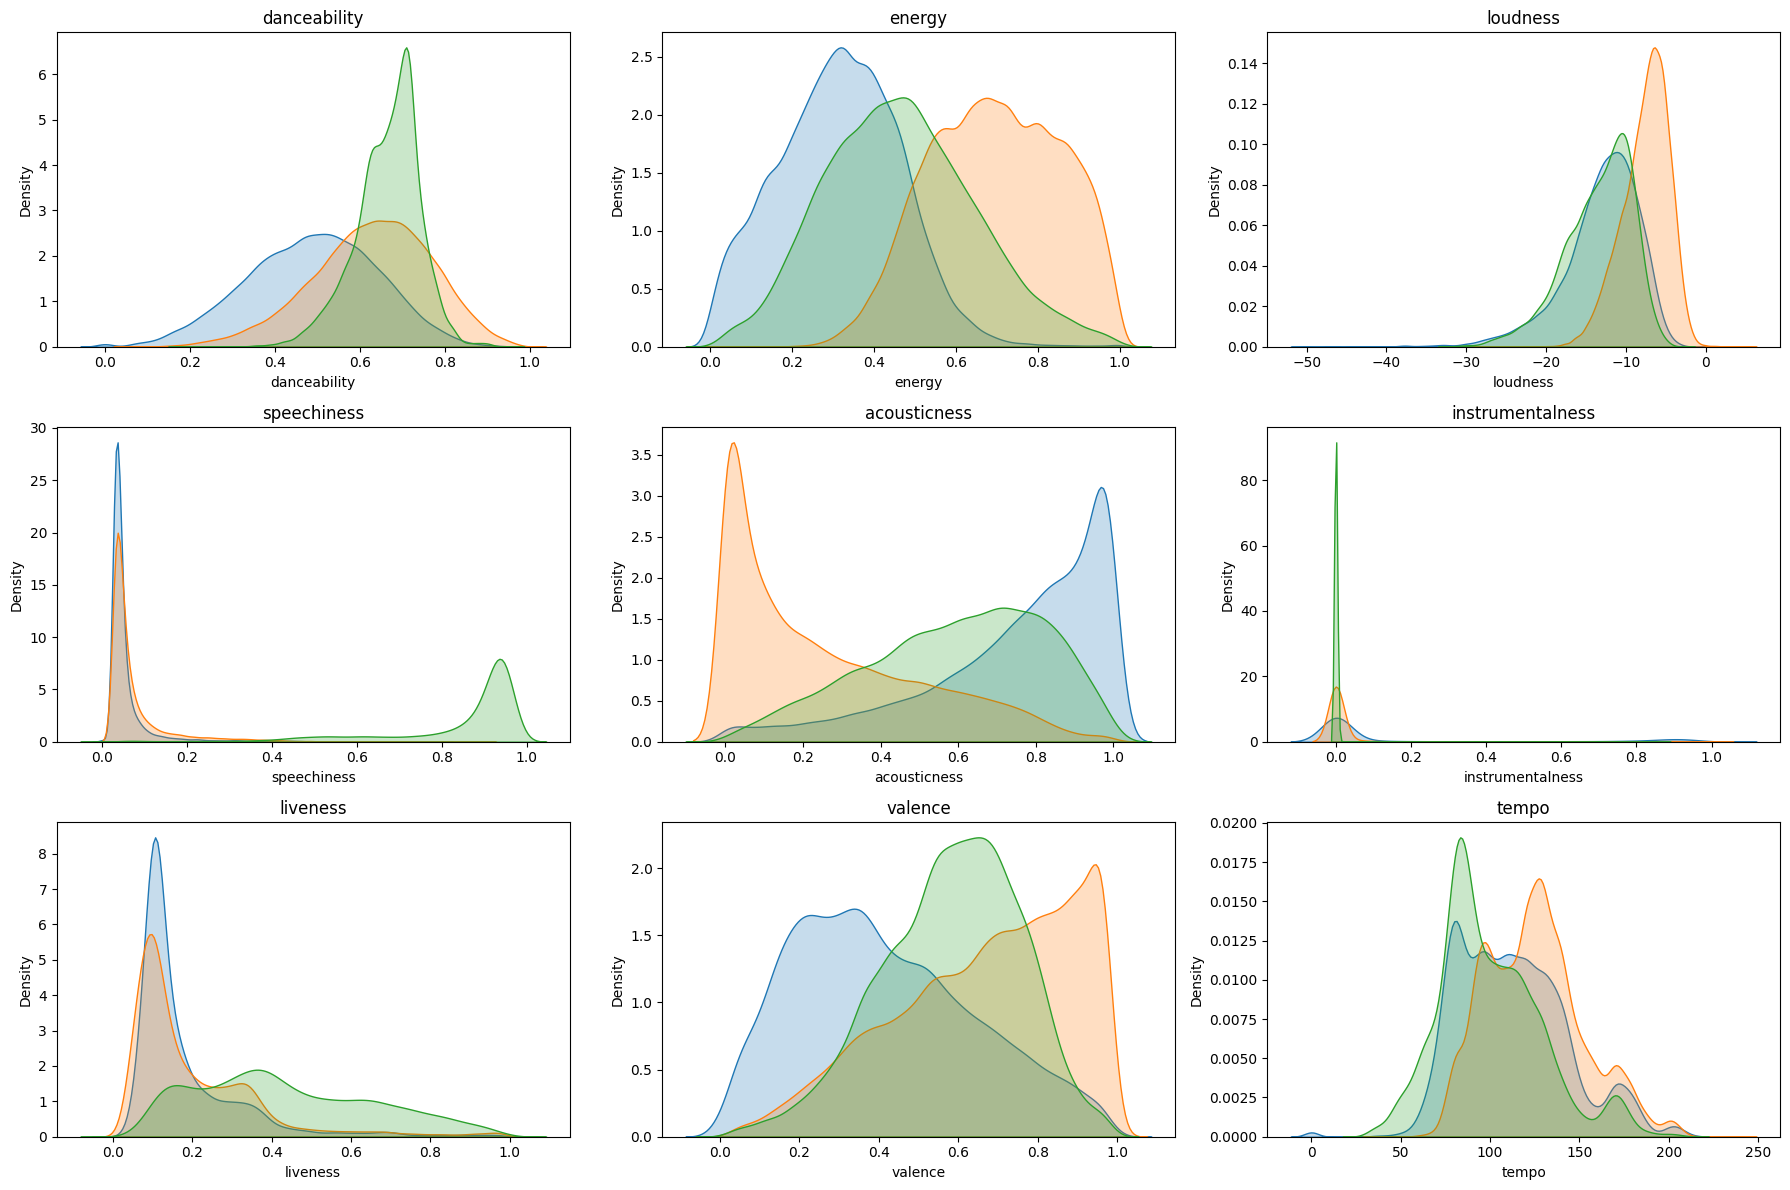

In [35]:
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(18,12))
axes = axes.flatten()

for i, feature in enumerate(features):
    
    for cluster in sorted(df_original['cluster'].unique()):
        sns.kdeplot(
            df_original[df_original['cluster'] == cluster][feature],
            fill=True,
            ax=axes[i],
            label=f'C{cluster}'
        )
    
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("final_clustered_music_data.csv", index=False)
print("\nFile saved as final_clustered_music_data.csv")